In [1]:
import pandas as pd
import numpy as np
import gower
from sklearn.neighbors import KNeighborsRegressor
from scipy.stats.contingency import crosstab

import load.load_dataset as ds

from umap import UMAP
from sklearn.cluster import HDBSCAN

import seaborn as sns
import matplotlib.pyplot as plt

import os
import joblib

import warnings
warnings.filterwarnings('ignore')
np.random.seed(0)

2026-09-26 11:35:44.871405: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
model_list = ['model1', 'model2', 'model3']

param_dict = joblib.load(os.path.join(os.getcwd(), "..", "parameters.joblib"))

for dataset in param_dict:
    print(f"########## {dataset} ##########")
    for param in param_dict[dataset]:
        print(f"{param}: {param_dict[dataset][param]}")
    print("\n")

########## adult ##########
n_clust: 1000
ensemble_medoid_k: 9
ensemble_medoid_th: 0.8
ensemble_random_k: 5
ensemble_random_th: 0.7
mean_medoid_k: 9
mean_medoid_th: 0.8
mean_random_k: 5
mean_random_th: 0.7


########## bank ##########
n_clust: 1000
ensemble_medoid_k: 7
ensemble_medoid_th: 0.8
mean_random_k: 9
mean_random_th: 0.75
ensemble_random_k: 7
ensemble_random_th: 0.75
mean_medoid_k: 11
mean_medoid_th: 0.8


########## beans ##########
n_clust: 225
ensemble_medoid_k: 9
ensemble_medoid_th: 0.85
mean_medoid_k: 9
mean_medoid_th: 0.9
ensemble_random_k: 5
ensemble_random_th: 0.75
mean_random_k: 7
mean_random_th: 0.8


########## cancer ##########
n_clust: 10
ensemble_medoid_k: 11
ensemble_medoid_th: 0.85
mean_medoid_k: 9
mean_medoid_th: 0.9
ensemble_random_k: 5
ensemble_random_th: 0.55
mean_random_k: 7
mean_random_th: 0.65


########## heloc ##########
n_clust: 130
ensemble_medoid_k: 15
ensemble_medoid_th: 0.8
mean_medoid_k: 13
mean_medoid_th: 0.8
ensemble_random_k: 11
ensemble_random

# Per dataset Hyperpar tuning
per dataset analysis of k_r and r_threshold

In [3]:
dataset_name = "bank"

neigh = "medoid" # medoid random
agg = "ensemble" # ensemble mean

methods_labels = ["IG", "DL", "LRP", agg]

folder = os.path.join(os.getcwd(), f"results_{neigh}")

In [4]:
dataset = ds.Dataset(dataset_name)

feature_names, categorical_features, categorical_names, ordinal,discrete, encoder, num_features = dataset.info()
X_train_or, X_train, y_train = dataset.train()
X_val_or, X_val, y_val = dataset.validation()
X_test_or, X_test, y_test = dataset.test()

print(X_train_or.shape, X_val_or.shape, X_test_or.shape)

(36168, 14) (8043, 14) (1000, 14)


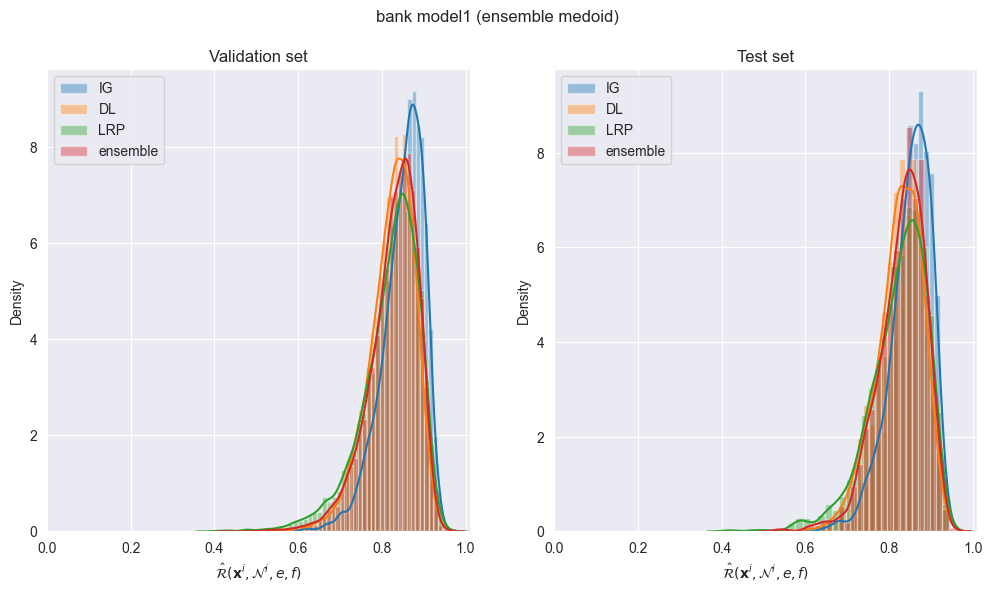

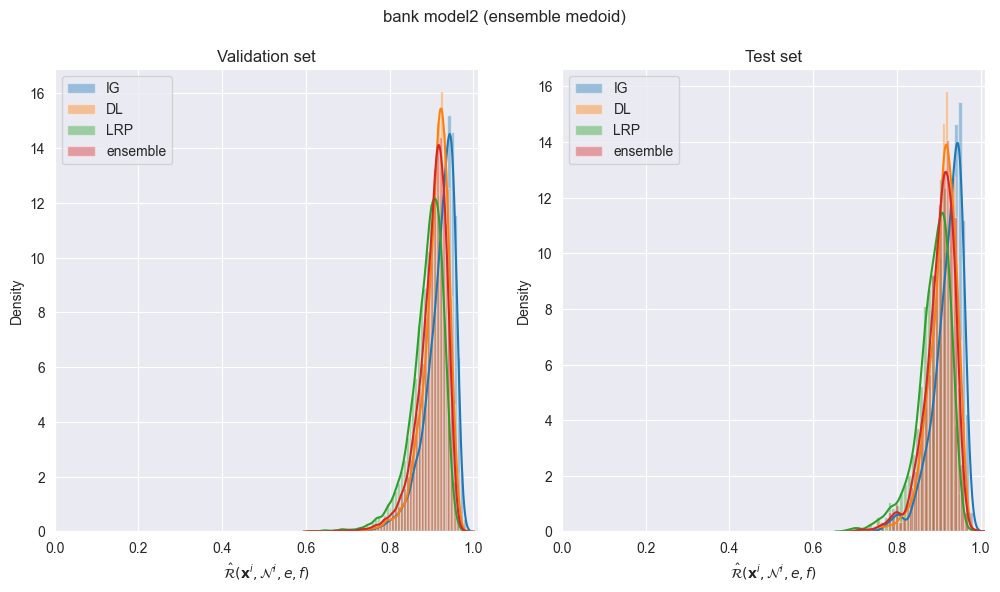

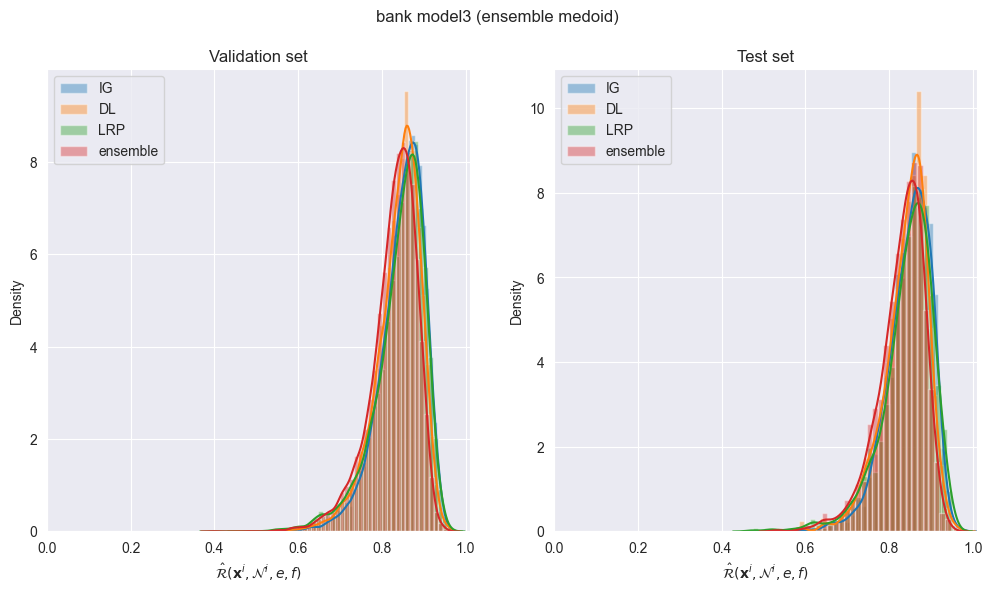

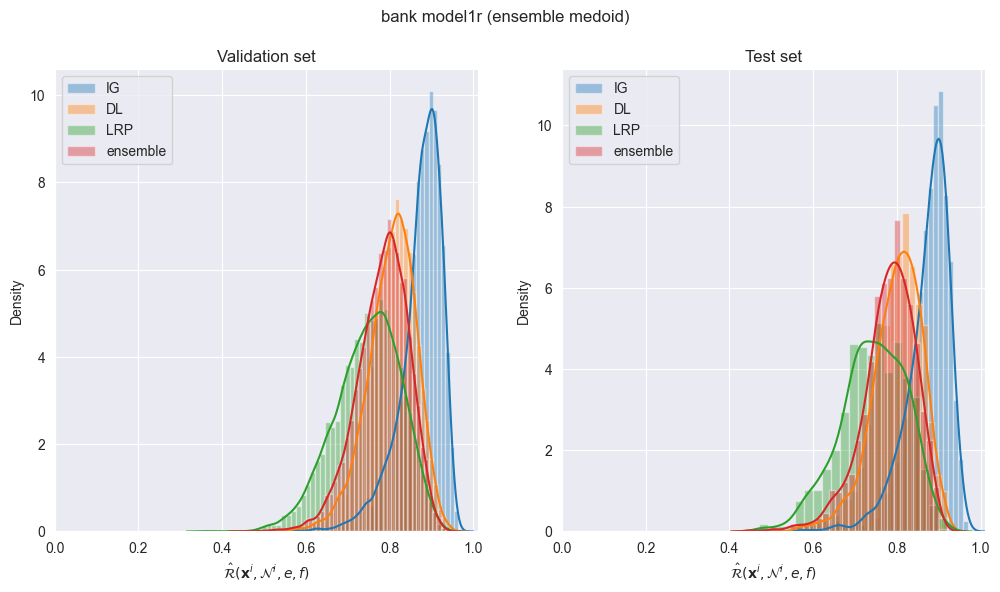

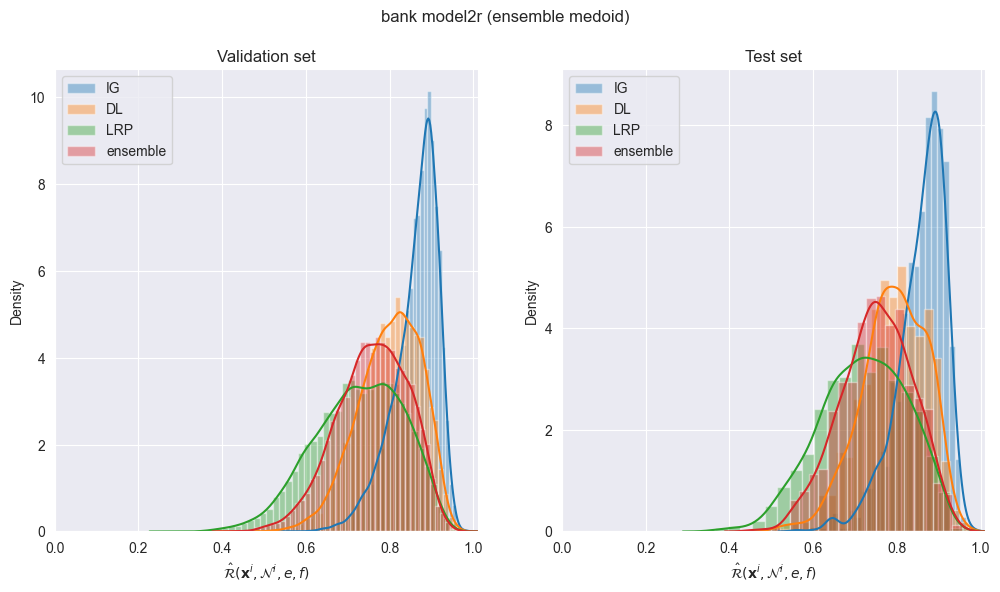

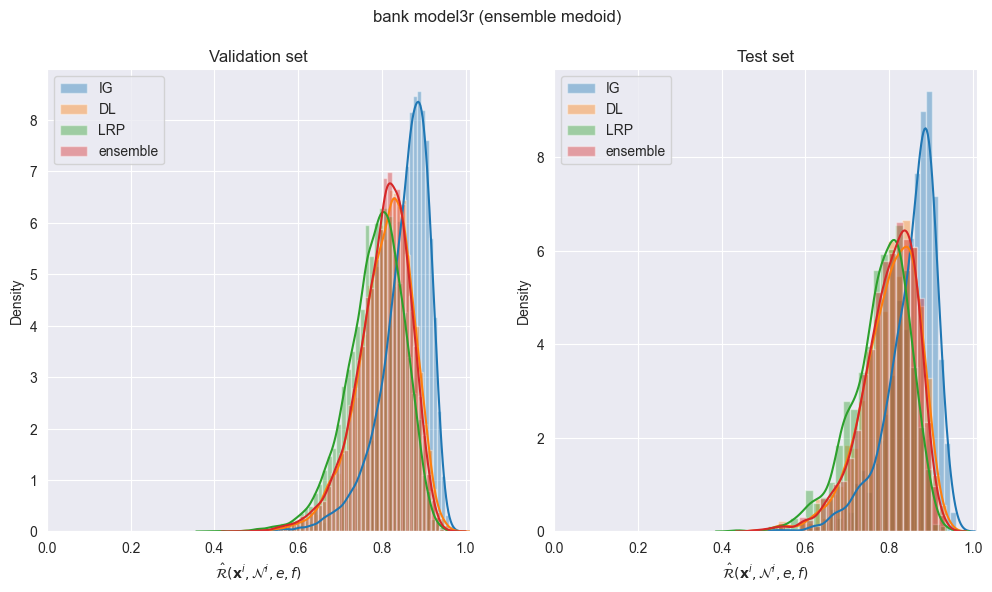

In [5]:
for model_name in model_list:
    folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")

    rho_valid = np.load(os.path.join(folder_, "validation", f"robustness_{agg}_{neigh}.npy"))
    rho_test = np.load(os.path.join(folder_, "test", f"robustness_{agg}_{neigh}.npy"))

    fig, ax = plt.subplots(1,2, figsize=(12,6))
    for i in range(len(methods_labels)):
        sns.distplot(rho_valid[:,i], ax = ax[0], label=methods_labels[i])
        sns.distplot(rho_test[:,i], ax= ax[1], label=methods_labels[i])

    ax[0].set_title("Validation set")
    ax[1].set_title("Test set")
    ax[0].legend()
    ax[1].legend()
    ax[0].set_xlim(0, 1.01)
    ax[1].set_xlim(0,1.01)
    ax[0].set_xlabel("$\hat{\mathcal{R}}(\mathbf{x}^i, \mathcal{N}^{i}, e, f)$")
    ax[1].set_xlabel("$\hat{\mathcal{R}}(\mathbf{x}^i, \mathcal{N}^{i}, e, f)$")
    plt.suptitle(f"{dataset_name} {model_name} ({agg} {neigh})")
    plt.show()

# confirm that the validation and test sets have comparable robustness distributions (prop.5)

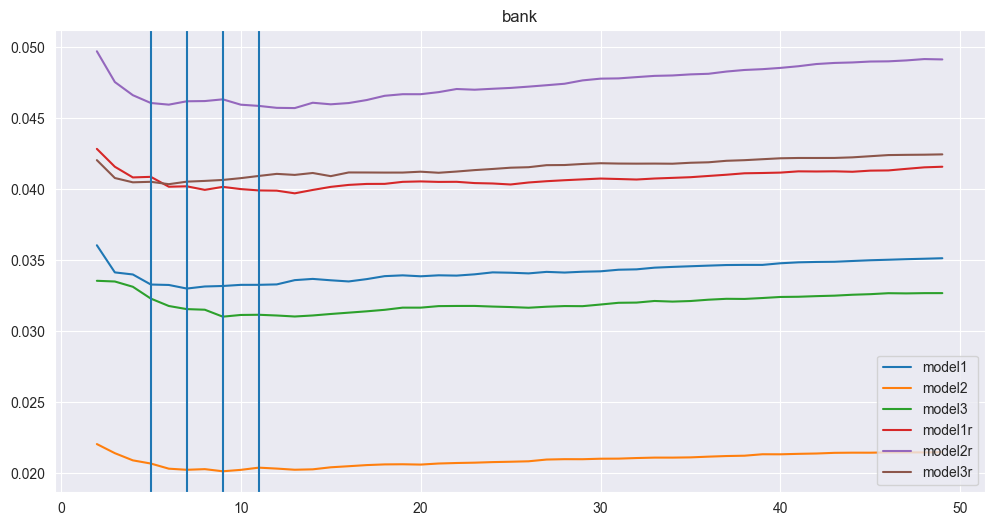

In [7]:
plt.figure(figsize=(12,6))
for model_name in [m for m in model_list]: # if m != 'model1r' and m != 'model2r' and m != 'model3r'
    folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")

    rho_valid = np.load(os.path.join(folder_, "validation", f"robustness_{agg}_{neigh}.npy"))
    rho_test = np.load(os.path.join(folder_, "test", f"robustness_{agg}_{neigh}.npy"))

    rho_valid = np.nan_to_num(rho_valid)

    tmp = []
    for k in range(2,50):
        regr = KNeighborsRegressor(n_neighbors=k).fit(X_val_or, rho_valid[:,3])
        rob_ = regr.predict(X_test_or)

        tmp.append(np.mean(np.abs(rho_test[:,3]-rob_)))
    
    plt.plot(range(2,50), tmp, label = model_name)

plt.axvline(x=5)
plt.axvline(x=7)
plt.axvline(x=9)
plt.axvline(x=11)
plt.title(dataset_name)
plt.legend()
plt.show()

In [6]:
k_r = 7
#param_dict[dataset_name][f"{agg}_{neigh}_k"] = k_r

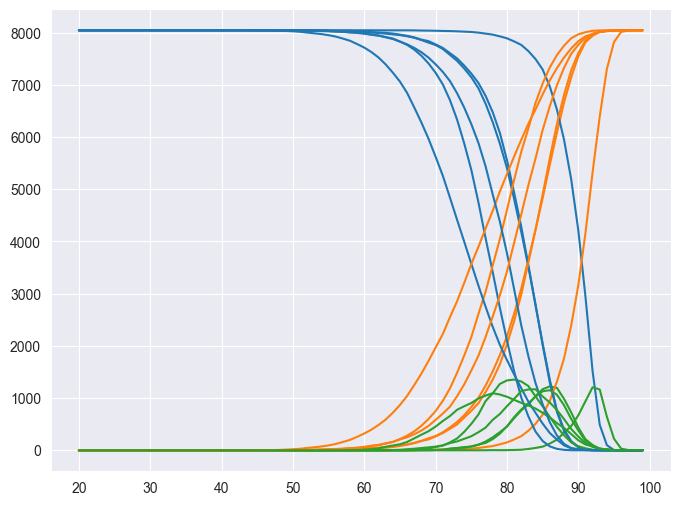

In [7]:
plt.figure(figsize=(8,6))
for model_name in [m for m in model_list]: # if m != 'model1' and m != 'model2' and m != 'model3'
    folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")

    rho_valid = np.load(os.path.join(folder_, "validation", f"robustness_{agg}_{neigh}.npy"))
    rho_valid = np.nan_to_num(rho_valid)
    rob_= rho_valid[:,3]

    regr = KNeighborsRegressor(n_neighbors=k_r).fit(X_val_or, rob_)
    rob_hat= regr.predict(X_val_or)

    non_robust = []
    robust = []
    other_=[]

    for th in range(20, 100):
        th = th/100
        
        robust.append(len(set.intersection(*map(set, [np.where(rob_ >= th)[0], np.where(rob_hat >= th)[0]]))))
        other_.append(len(set.intersection(*map(set, [np.where(rob_ >= th)[0], np.where(rob_hat < th)[0]]))))
        non_robust.append(len(np.where(rob_<th)[0]))

    plt.plot(range(20, 100), robust,  c = 'tab:blue')
    plt.plot(range(20, 100), non_robust,  c = 'tab:orange')
    plt.plot(range(20, 100), other_,  c ='tab:green')
plt.show()

In [8]:
th = 0.8
#param_dict[dataset_name][f"{agg}_{neigh}_th"] = th

#joblib.dump(param_dict, os.path.join(os.getcwd(), "parameters.joblib"))

In [10]:
for dataset in param_dict:
    print(f"########## {dataset} ##########")
    for param in param_dict[dataset]:
        print(f"{param}: {param_dict[dataset][param]}")
    print("\n")

########## adult ##########
n_clust: 1000
ensemble_medoid_k: 9
ensemble_medoid_th: 0.8
ensemble_random_k: 5
ensemble_random_th: 0.7
mean_medoid_k: 9
mean_medoid_th: 0.8
mean_random_k: 5
mean_random_th: 0.7


########## bank ##########
n_clust: 1000
ensemble_medoid_k: 7
ensemble_medoid_th: 0.8
mean_random_k: 9
mean_random_th: 0.75
ensemble_random_k: 7
ensemble_random_th: 0.75
mean_medoid_k: 11
mean_medoid_th: 0.8


########## beans ##########
n_clust: 225
ensemble_medoid_k: 9
ensemble_medoid_th: 0.85
mean_medoid_k: 9
mean_medoid_th: 0.9
ensemble_random_k: 5
ensemble_random_th: 0.75
mean_random_k: 7
mean_random_th: 0.8


########## cancer ##########
n_clust: 10
ensemble_medoid_k: 11
ensemble_medoid_th: 0.85
mean_medoid_k: 9
mean_medoid_th: 0.9
ensemble_random_k: 5
ensemble_random_th: 0.55
mean_random_k: 7
mean_random_th: 0.65


########## heloc ##########
n_clust: 130
ensemble_medoid_k: 15
ensemble_medoid_th: 0.8
mean_medoid_k: 13
mean_medoid_th: 0.8
ensemble_random_k: 11
ensemble_random

# Per Model Check correctness of Hyperpar

Check for correctness of chosen k and th for each model

In [13]:
model_name = 'model3r'

k_r = param_dict[dataset_name][f"{agg}_{neigh}_k"]
th = param_dict[dataset_name][f"{agg}_{neigh}_th"]

print(model_name, dataset_name)

folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")
rho_valid = np.load(os.path.join(folder_, "validation", f"robustness_{agg}_{neigh}.npy"))
rho_test = np.load(os.path.join(folder_, "test", f"robustness_{agg}_{neigh}.npy"))
rho_valid = np.nan_to_num(rho_valid)
regr = KNeighborsRegressor(n_neighbors=k_r).fit(X_val_or, rho_valid[:,3])
rob_hat = regr.predict(X_test_or) # HERE we predict the robustness of the test set, via the knnregressor previously trained on the validation set
rob_= rho_test[:,3]

list_regressor = rob_hat >= th
list_real = rob_ >= th

overall = np.array(list_regressor).astype(int) + np.array(list_real).astype(int)
total = len(overall)
robust = len(np.where(overall==2)[0])
non_robust = len(np.where(list_real == 0)[0])
maybe = total - robust - non_robust

print("Robust", robust, "\nMaybe", maybe, "\nNon Robust", non_robust,"\nTotal", total)

# I want small maybe and robust >> 0

model3r bank
Robust 439 
Maybe 119 
Non Robust 442 
Total 1000


In [14]:
#joblib.dump(param_dict, os.path.join(os.getcwd(), "parameters.joblib"))

 check for propriety 2: dataset points that are close in the feature space, have similar robustness score

In [15]:
umap = UMAP(n_components=2, random_state=0, n_jobs=1)
X_new = umap.fit_transform(X_val_or)

hdbscan = HDBSCAN(min_cluster_size=100)
hdbscan.fit(X_new)
hdbs_labels = hdbscan.labels_
print(np.unique(hdbs_labels))

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23]


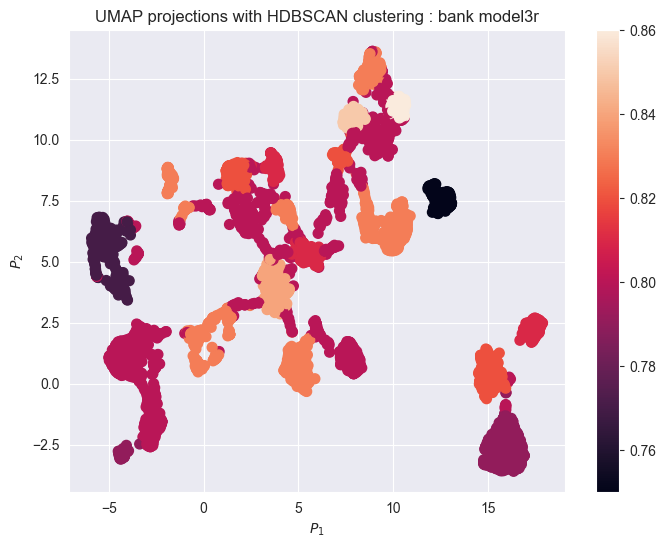

In [16]:
folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")
rho_valid = np.load(os.path.join(folder_, "validation", f"robustness_{agg}_{neigh}.npy"))

cols = []
for cl_idx in np.unique(hdbs_labels):
    rho_tmp = rho_valid[hdbs_labels==cl_idx]
    cols.append(np.round(np.nanmean(rho_tmp), 2))

cols = np.array(cols)
colors = cols[hdbs_labels]

plt.figure(figsize=(8,6))

plt.scatter(X_new[:,0], X_new[:,1], c=colors, s=50)
plt.title(f"UMAP projections with HDBSCAN clustering : {dataset_name} {model_name}")
plt.xlabel("$P_1$")
plt.ylabel("$P_2$")
plt.colorbar()
plt.show()

# EXECUTION
Using parameters in parameters.joblib fit the correct final krr regressor and produce the excel needed to compute the final ROC-AUC results

In [9]:
for neigh in ["medoid", "random"]:
    folder = os.path.join(os.getcwd(), "..", f"results_{neigh}")
    for agg in  ["ensemble", "mean"]:
        final = []
        for dataset_name in param_dict.keys():

            dataset = ds.Dataset(dataset_name)
            X_val_or, X_val, y_val = dataset.validation()
            X_test_or, X_test, y_test = dataset.test()

            dim = X_test_or.shape[0]
            k_r = param_dict[dataset_name][f"{agg}_{neigh}_k"]

            gt = np.argmax(y_test.detach().numpy(), axis=1)
            model_pred = []
            for model_name in model_list:
                model = dataset.load_model(model_name)
                model_pred.append(np.argmax(model(X_test).detach().numpy(), axis=1))

            model_pred=np.array(model_pred)

            concordant_mask = np.all(model_pred == model_pred[0], axis=0)
            models3 = concordant_mask.astype(int)

            for model_name in model_list:
                folder_ = os.path.join(folder, f"{dataset_name}_{model_name}")

                rho_valid = np.load(os.path.join(folder_, "validation", f"robustness_{agg}_{neigh}.npy"))
                rho_test = np.load(os.path.join(folder_, "test", f"robustness_{agg}_{neigh}.npy"))

                rho_valid = np.nan_to_num(rho_valid)

                regr = KNeighborsRegressor(n_neighbors=k_r).fit(X_val_or, rho_valid[:,3])
                rob_hat = regr.predict(X_test_or)
                rob_= rho_test[:,3]

                for th in np.arange(0,1, 0.01):
                    list_regressor = rob_hat >= th
                    list_real = rob_ >= th

                    overall = np.array(list_regressor).astype(int) + np.array(list_real).astype(int)
                    ROBUST = np.where(overall==2)[0]
                    NONROBUST = np.where(list_real == 0)[0]

                    total = len(overall)
                    robust = len(ROBUST)
                    non_robust = len(NONROBUST)
                    maybe = total - robust - non_robust

                    th_ = rob_ >= th

                    contingency = crosstab(models3, th_, levels=([1,0], [True, False]))

                    robust_cross = contingency.count[:,0]
                    non_robust_cross = contingency.count[:,1]

                    final.append([dataset_name, model_name, th, robust, maybe, non_robust, total, robust_cross[0], robust_cross[1], np.sum(th_), non_robust_cross[0], non_robust_cross[1], dim-np.sum(th_)])

        df = pd.DataFrame(final)
        df.columns = ["dataset", "model", "threshold", "robust", "maybe", "non robust", "len", "robust concordant", "robust discordant", "tot robust", "non robust concordant", "non robust discordant",  "tot non robust"]
        df.to_excel(os.path.join(os.getcwd(), "results_roc_auc", f"{agg}_{neigh}_threshold.xlsx"), index=False)


# Analysis

In [3]:
df_ens = pd.read_excel(os.path.join(os.getcwd(), "results_roc_auc", "ensemble_medoid_threshold.xlsx"))
df_mean = pd.read_excel(os.path.join(os.getcwd(), "results_roc_auc", "mean_medoid_threshold.xlsx"))
df_ens_random = pd.read_excel(os.path.join(os.getcwd(), "results_roc_auc", "ensemble_random_threshold.xlsx"))
df_mean_random = pd.read_excel(os.path.join(os.getcwd(), "results_roc_auc", "mean_random_threshold.xlsx"))

In [5]:
# Table 1

model_baseline = "model1"

df_e_t1 = df_ens[np.isclose(df_ens["threshold"], 0.80) & df_ens["model"].isin([model_baseline])].copy()
df_m_t1 = df_mean[np.isclose(df_mean["threshold"], 0.80) & df_mean["model"].isin([model_baseline])].copy()

df_e_t1["rob_%"] = 100 * df_e_t1["robust"] / df_e_t1["len"]
df_e_t1["maybe_%"] = 100 * df_e_t1["maybe"] / df_e_t1["len"]
df_e_t1["non_rob_%"] = 100 * df_e_t1["non robust"] / df_e_t1["len"]
df_m_t1["rob_%"] = 100 * df_m_t1["robust"] / df_m_t1["len"]
df_m_t1["maybe_%"] = 100 * df_m_t1["maybe"] / df_m_t1["len"]
df_m_t1["non_rob_%"] = 100 * df_m_t1["non robust"] / df_m_t1["len"]

df_e_t1 = df_e_t1.set_index("dataset")[["len", "rob_%", "maybe_%", "non_rob_%"]]
df_m_t1 = df_m_t1.set_index("dataset")[["rob_%", "maybe_%", "non_rob_%"]]

table1 = df_e_t1.join(df_m_t1, lsuffix="_ens", rsuffix="_mean")
table1 = table1.round(1)

table1.columns = pd.MultiIndex.from_tuples([
    ("", "Dtest"),
    ("Ensemble", "Robust"),
    ("Ensemble", "Uncertain"),
    ("Ensemble", "Non Robust"),
    ("Mean", "Robust"),
    ("Mean", "Uncertain"),
    ("Mean", "Non Robust"),
])

table1 = table1.reindex([d for d in param_dict.keys() if d in table1.index])
table1.index.name = None
table1.columns.names = [None, None]
display(table1)

Ensemble                        Mean                     
          Dtest   Robust Uncertain Non Robust Robust Uncertain Non Robust
adult      1000     63.4       7.1       29.5   72.6       7.3       20.1
bank       1000     65.2       7.1       27.7   44.6      16.4       39.0
beans       500     74.6       7.2       18.2   93.0       2.2        4.8
cancer       50     62.0      12.0       26.0  100.0       0.0        0.0
heloc       500     62.8       9.2       28.0   60.6      14.0       25.4
mushroom    400      0.0       1.2       98.8    0.0       0.0      100.0
ocean     10000     79.2       5.6       15.2   53.5      16.0       30.5
wine        200      7.5      26.5       66.0   56.5      11.0       32.5

In [6]:
# Table 2

df_t2 = df_ens[np.isclose(df_ens["threshold"], 0.80) & df_ens["model"].isin([model_baseline])].copy()

df_t2["robust_agree"] = 100 * df_t2["robust concordant"] / df_t2["tot robust"]
df_t2["robust_disagree"] = 100 * df_t2["robust discordant"] / df_t2["tot robust"]
df_t2["nonrobust_agree"] = 100 * df_t2["non robust concordant"] / df_t2["tot non robust"]
df_t2["nonrobust_disagree"] = 100 * df_t2["non robust discordant"] / df_t2["tot non robust"]

table2 = df_t2.set_index("dataset")[[
    "robust_agree", "robust_disagree", "tot robust",
    "nonrobust_agree", "nonrobust_disagree", "tot non robust"
]].round(2)

table2.columns = pd.MultiIndex.from_tuples([
    ('Robust', 'Agree'),
    ('Robust', 'Disagree'),
    ('Robust', 'N. points'),
    ('Non Robust', 'Agree'),
    ('Non Robust', 'Disagree'),
    ('Non Robust', 'N. points'),
])
table2 = table2.reindex([d for d in param_dict.keys() if d in table2.index])
table2.index.name = None
table2.columns.names = [None, None]
display(table2)

Robust                    Non Robust                   
           Agree Disagree N. points      Agree Disagree N. points
adult      93.76     6.24       705      80.68    19.32       295
bank       95.99     4.01       723      90.25     9.75       277
beans      95.35     4.65       409      95.60     4.40        91
cancer     91.89     8.11        37      92.31     7.69        13
heloc      82.22    17.78       360      56.43    43.57       140
mushroom  100.00     0.00         5     100.00     0.00       395
ocean      85.20    14.80      8475      80.33    19.67      1525
wine       94.12     5.88        68      92.42     7.58       132

In [7]:
for df in [df_ens, df_mean, df_ens_random, df_mean_random]:

    df["true positive"] = df["robust concordant"]
    df["false positive"] = df["robust discordant"]

    df["false negative"] = df["non robust concordant"]
    df["true negative"] = df["non robust discordant"]

    df["positive"] = df["true positive"]+df["false negative"]
    df["negative"] = df["true negative"]+df["false positive"]

    df["TPR"] = df["true positive"]/df["positive"]
    df["FPR"] = df["false positive"]/df["negative"]


    df['acc'] = (df['true positive'] + df['true negative'])/df["len"]

    df = df.fillna(0, inplace=True)

In [8]:
df_ens

,dataset,model,threshold,robust,maybe,non robust,len,robust concordant,robust discordant,tot robust,...,Unnamed: 16,true positive,false positive,false negative,true negative,positive,negative,TPR,FPR,acc
0,adult,model1,0.00,1000,0,0,1000,899,101,1000,...,0.0,899,101,0,0,899,101,1.000000,1.000000,0.899
1,adult,model1,0.01,1000,0,0,1000,899,101,1000,...,0.0,899,101,0,0,899,101,1.000000,1.000000,0.899
2,adult,model1,0.02,1000,0,0,1000,899,101,1000,...,0.0,899,101,0,0,899,101,1.000000,1.000000,0.899
3,adult,model1,0.03,1000,0,0,1000,899,101,1000,...,0.0,899,101,0,0,899,101,1.000000,1.000000,0.899
4,adult,model1,0.04,1000,0,0,1000,899,101,1000,...,0.0,899,101,0,0,899,101,1.000000,1.000000,0.899
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,wine,model3,0.95,0,6,194,200,4,2,6,...,0.0,4,2,182,12,186,14,0.021505,0.142857,0.080
2396,wine,model3,0.96,0,3,197,200,2,1,3,...,0.0,2,1,184,13,186,14,0.010753,0.071429,0.075
2397,wine,model3,0.97,0,1,199,200,1,0,1,...,0.0,1,0,185,14,186,14,0.005376,0.000000,0.075
2398,wine,model3,0.98,0,1,199,200,1,0,1,...,0.0,1,0,185,14,186,14,0.005376,0.000000,0.075


In [9]:
from sklearn.metrics import auc

acc = []
modelmax = []

for i, df in enumerate([df_ens, df_mean, df_ens_random, df_mean_random]):
    if i< 2:
        neigh = "medoid"
    else:
        neigh="random"

    if i%2 ==0:
        agg = "ensemble"
    else:
        agg="mean"

    for dataset_name in param_dict.keys():
        acc_ = 0
        max_ = 0
        for model_name in model_list:

            false_pos_rate = np.array(df["FPR"][df["dataset"]==dataset_name][df["model"]==model_name])[::-1]
            true_pos_rate = np.array(df["TPR"][df["dataset"]==dataset_name][df["model"]==model_name])[::-1]

            tmp = pd.DataFrame({'x':false_pos_rate, 'y':true_pos_rate})
            results = tmp#.drop_duplicates()

            x = results['x'].values
            y = results['y'].values

            try:
                area = auc(x,y)
            except:
                area = 1 

            acc_ = acc_ + area

            ma_ = max(max_, area)
        
        acc_ = acc_/len(model_list)
        acc += [[dataset_name, neigh, agg, acc_]]
        modelmax += [[dataset_name, neigh, agg, max_]]


df_auc = pd.DataFrame(acc, columns=["dataset", "neigh", "method", "auc"])

df_auc_max = pd.DataFrame(modelmax, columns=["dataset", "neigh", "method", "auc"])

In [10]:
df_auc
for dataset_name in param_dict.keys():
    tmp = df_auc[df_auc["dataset"]==dataset_name]

    tmp = tmp.sort_values(by=['auc'], ascending=False)
    tmp['auc'] = np.round(tmp['auc'], 4)
    print(tmp)
    print("_---------------------")

   dataset   neigh    method     auc
16   adult  random  ensemble  0.8284
24   adult  random      mean  0.8077
0    adult  medoid  ensemble  0.7018
8    adult  medoid      mean  0.6695
_---------------------
   dataset   neigh    method     auc
1     bank  medoid  ensemble  0.6670
17    bank  random  ensemble  0.6612
25    bank  random      mean  0.4696
9     bank  medoid      mean  0.3883
_---------------------
   dataset   neigh    method     auc
2    beans  medoid  ensemble  0.5711
10   beans  medoid      mean  0.4854
18   beans  random  ensemble  0.4842
26   beans  random      mean  0.4067
_---------------------
   dataset   neigh    method     auc
11  cancer  medoid      mean  0.7400
3   cancer  medoid  ensemble  0.7346
19  cancer  random  ensemble  0.6766
27  cancer  random      mean  0.6612
_---------------------
   dataset   neigh    method     auc
12   heloc  medoid      mean  0.6673
4    heloc  medoid  ensemble  0.6640
20   heloc  random  ensemble  0.6262
28   heloc  random  

In [11]:
# Table 3

pivot = df_auc.copy()
pivot['auc'] = np.round(pivot['auc'], 4)

pivot['col'] = pivot['neigh'] + '_' + pivot['method']
table3 = pivot.pivot(index='dataset', columns='col', values='auc')
table3 = table3[['medoid_ensemble', 'medoid_mean', 'random_ensemble', 'random_mean']]
table3.columns = pd.MultiIndex.from_tuples([
    ('Medoid', 'Ensemble'),
    ('Medoid', 'Mean'),
    ('Random', 'Ensemble'),
    ('Random', 'Mean'),
])

table3 = table3.reindex([d for d in param_dict.keys() if d in table3.index])
table3 = table3.drop('mushroom', axis=0) # dont display mushroom
table3.index.name = None
table3.columns.names = [None, None]
def bold_max(row):
    return ['font-weight: bold' if v == row.max() else '' for v in row]
display(table3.style.apply(bold_max, axis=1))

(100, 26)
(100, 26)
(100, 26)


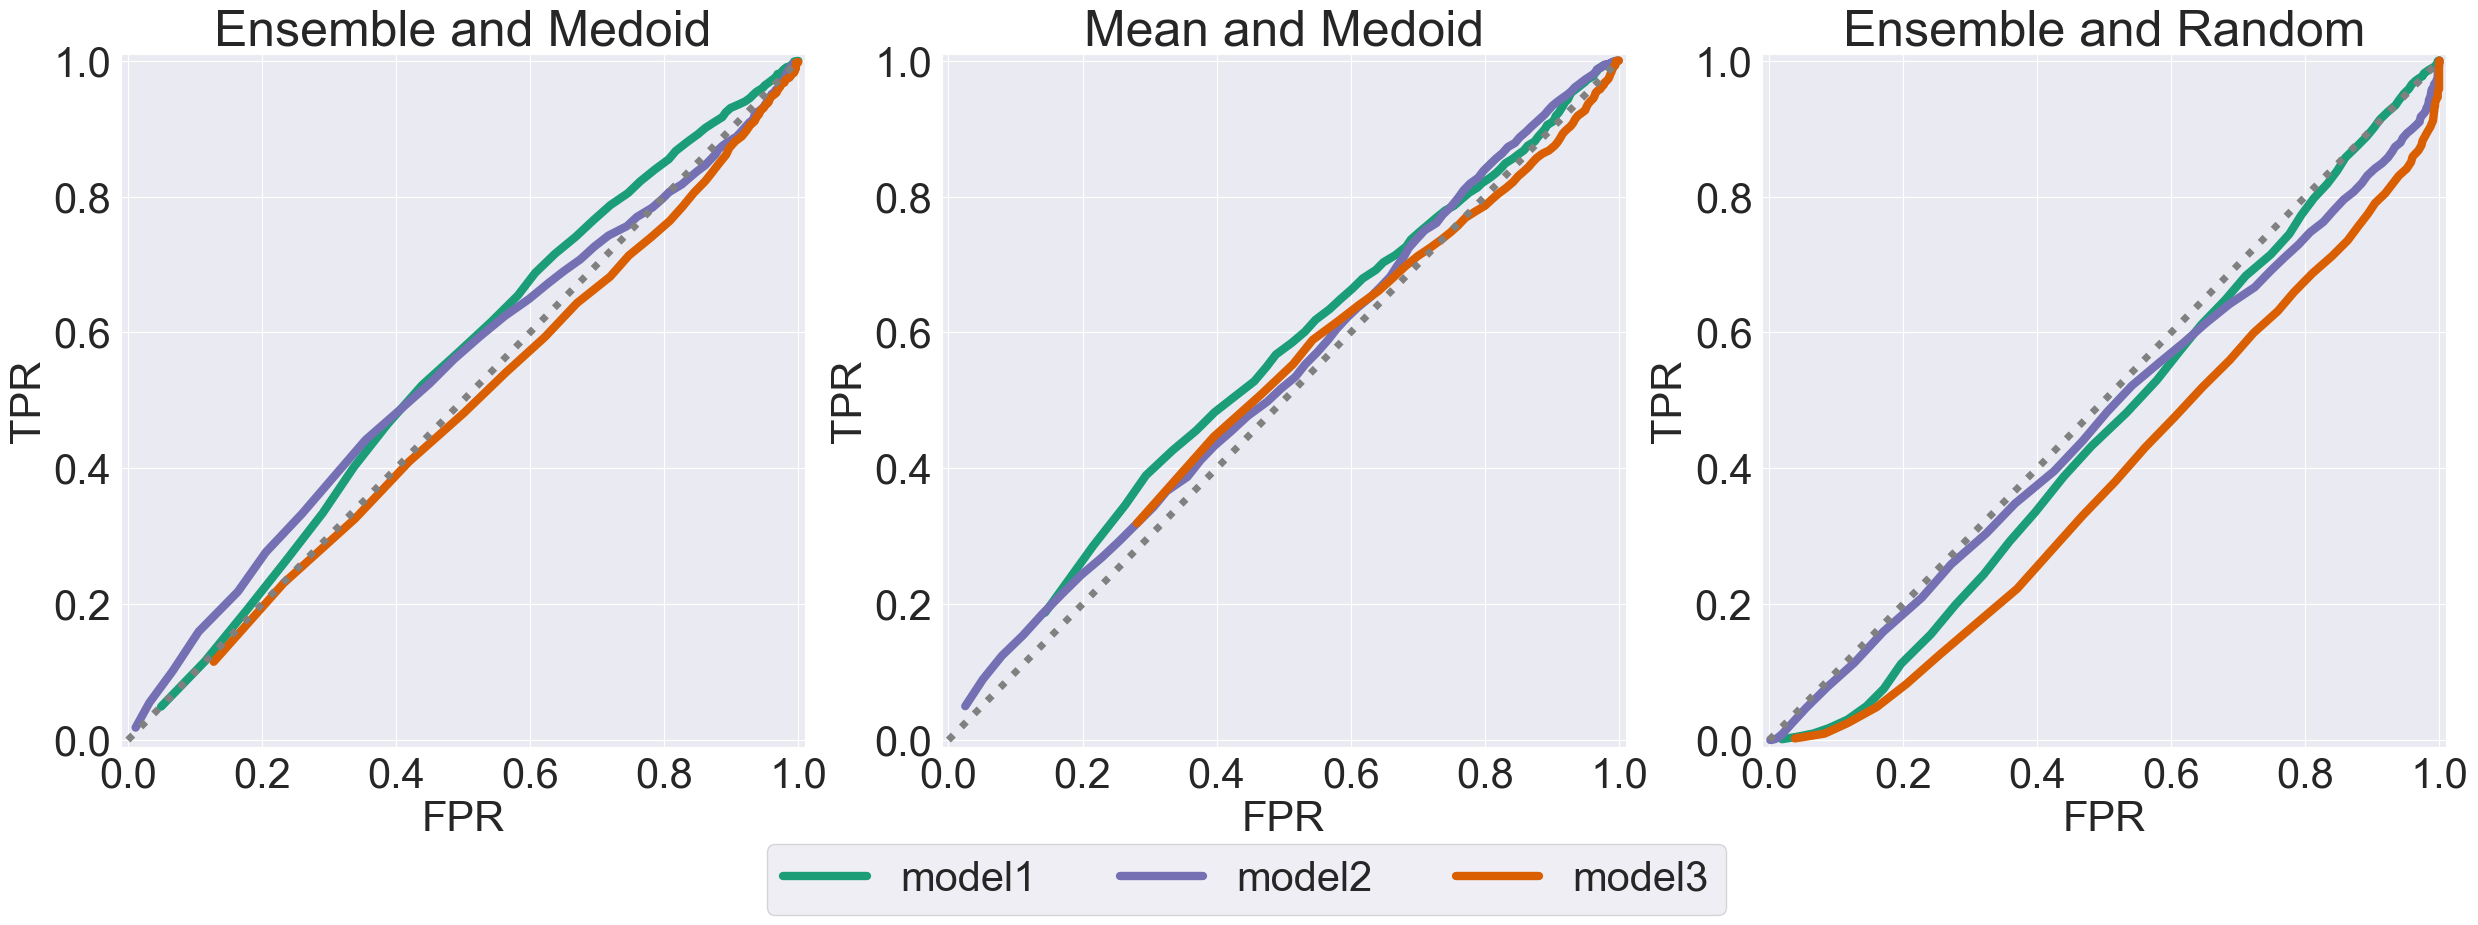

In [15]:
x_ = "FPR"
y_ = "TPR"

fig, ax = plt.subplots(1,3, figsize = (30,9))

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 30

linewidth = 6

model_colors = {f"{model_list[0]}": "#1b9e77",
                f"{model_list[1]}": "#7570b3",
                f"{model_list[2]}": "#d95f02"
                }

dataset_name = "ocean"

for i, model_name in enumerate(model_colors.keys()):
    df1 = df_ens
    df2 = df_mean

    de = df1[df1["dataset"]==dataset_name][df1["model"]==model_name]
    dd = df2[df2["dataset"]==dataset_name][df2["model"]==model_name]

    print(de.shape)

    ax[0].plot(de[x_], de[y_], label= f"Model {i+1}", c = model_colors[model_name], linewidth = linewidth, linestyle = "-")
    ax[1].plot(dd[x_], dd[y_],  label= f"Model {i+1}", c = model_colors[model_name], linewidth = linewidth, linestyle = "-")
   

for i, model_name in enumerate(model_colors.keys()):
    df1 = df_ens_random

    de = df1[df1["dataset"]==dataset_name][df1["model"]==model_name]
    ax[2].plot(de[x_], de[y_], label= f"Model {i+1}", c = model_colors[model_name], linewidth = linewidth, linestyle = "-")
    
    
for col in range(3):
    ax[col].set_ylim(-0.01,1.01)
    ax[col].set_xlim(-0.01,1.01)
    ax[col].set_xlabel("FPR")
    ax[col].set_ylabel("TPR")
    ax[col].set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax[col].plot(np.linspace(0,1), np.linspace(0,1), ":", c= "gray", linewidth = 5)

ax[0].set_title("Ensemble and Medoid")
ax[1].set_title("Mean and Medoid")
ax[2].set_title("Ensemble and Random")

fig.legend(list(model_colors.keys()), loc='lower center', ncol=3, bbox_to_anchor=(0.5,-0.1), bbox_transform=fig.transFigure)
plt.show()